<a href="https://colab.research.google.com/github/vcellmike/PatternsFormation/blob/main/Working/To_Silico_Conversion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
! chdir "content" && tar -xf real_images_6-29-25.zip && echo "Real images unzipped" && chdir ..

"Real images unzipped" 


In [4]:
############## Define paths ####################

import os

path = "./content/real_images_6-29-25"

filenames = []
filenames_trunc = []

for filename in sorted(os.listdir(path), key=lambda x: int(x.split(".")[0])):
    if os.path.isfile(os.path.join(path, filename)):
        filenames.append(path + '/' + filename)
        filenames_trunc.append(filename)

In [6]:
import pandas as pd

RealImages_df = pd.DataFrame(
    {
        'filename': filenames,
        'filenames_trunc' : filenames_trunc
    }
)

RealImages_df['filename'][0]
RealImages_df

,filename,filenames_trunc
0,./content/real_images_6-29-25/1.png,1.png
1,./content/real_images_6-29-25/2.png,2.png
2,./content/real_images_6-29-25/3.png,3.png
3,./content/real_images_6-29-25/4.png,4.png
4,./content/real_images_6-29-25/5.png,5.png
5,./content/real_images_6-29-25/6.png,6.png
6,./content/real_images_6-29-25/7.png,7.png
7,./content/real_images_6-29-25/8.png,8.png
8,./content/real_images_6-29-25/9.png,9.png
9,./content/real_images_6-29-25/10.png,10.png


In [8]:
### Utility Functions

from PIL import Image, ImageEnhance
import math

## Returns the image object and path
## Input - Index of the file within the dataframe
def pull_from_df(index, show=True):
  path = RealImages_df.iloc[index]['filename']
  img_obj = Image.open(path)
  if show:
    # if the show variable is True, then display the image
    display(img_obj)
  else:
    pass
  return path,img_obj

## Main algorithm
## Input - image_object to be worked on, contrast (T/F), show the enhanced image (T/F), and enhance factor.
## Returns an image object
def round_pixels_by_intensity(image_obj, threshold, display_enhanced=True, enhance=True, enhance_factor=1.5):
  """
    Multiple inputs:
      Image Object - the PIL Image object
      Threshold - The threshold at which a pixel is either filled with white or black
      Display_Enhanced - Whether to display the enhanced image. Defaults to True. Only used if enhance is True.
      Enhance - Whether to enhance the image. Defaults to True.
      Enhance_Factor - The factor to enhance the image by. Defaults to 1.5
  """
  if enhance:
    enhancer = ImageEnhance.Contrast(image_obj)
    img_enhanced = enhancer.enhance(enhance_factor)
    if display_enhanced: display(img_enhanced)
    image_obj = img_enhanced
  else:
    pass
  image_obj = image_obj.convert('L').point(lambda x: 0 if x < threshold else 255, '1')
  return image_obj

# Save the image to the specified path
def save_image(img_obj, path):
  img_obj.save(path)

### Current Status
Below are the current statuses of the images.

**Note**:

Blackwashed = too dark (ie. pigment is overexpressed)

Whitewashed = too light (ie. pigment is underexpressed)

1.png - Satisfactory

2 - Satisfactory

3 - Blackwashed

4 - Blackwashed

5- Whitewashed

6 - Misc.

7 - Satisfactory

8 - Blackwashed

9 - Whitewashed

10 - Blackwashed (detects 1 spot that does not exist)

11 - Blackwashed

12 - Blackwashed

13 - Blackwashed

**Complete Count:**
 - 6/13 - Blackwashed
 - 3/13 - Whitewashed
 - 3/13 - Satisfactory
 - 1/13 - Miscellaneous issues

**Hypothesis**: Increasing the threshold will eliminate blackwashing/oversensitivity and improve accuracy. To be tested 7/2/2025.

./content/real_images_6-29-25/1.png


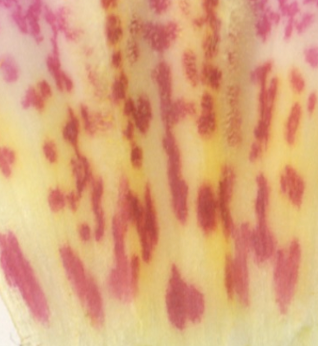

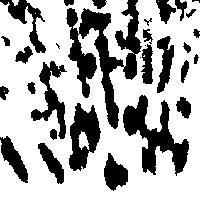

./content/real_images_6-29-25/2.png


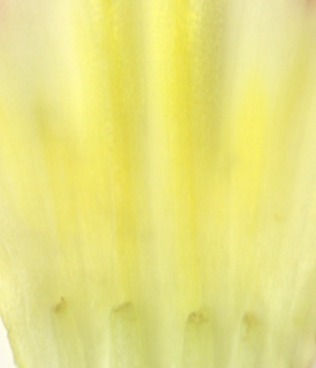

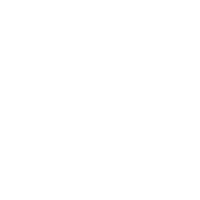

./content/real_images_6-29-25/3.png


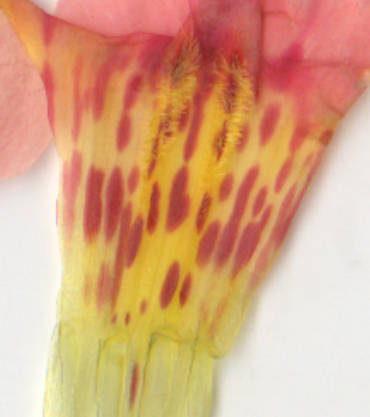

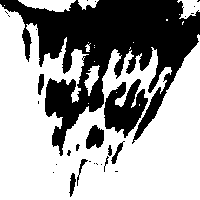

./content/real_images_6-29-25/4.png


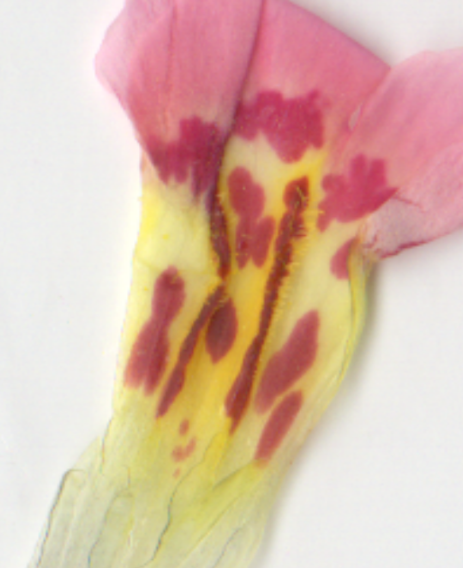

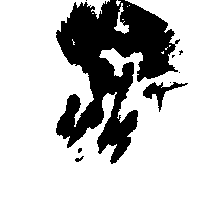

./content/real_images_6-29-25/5.png


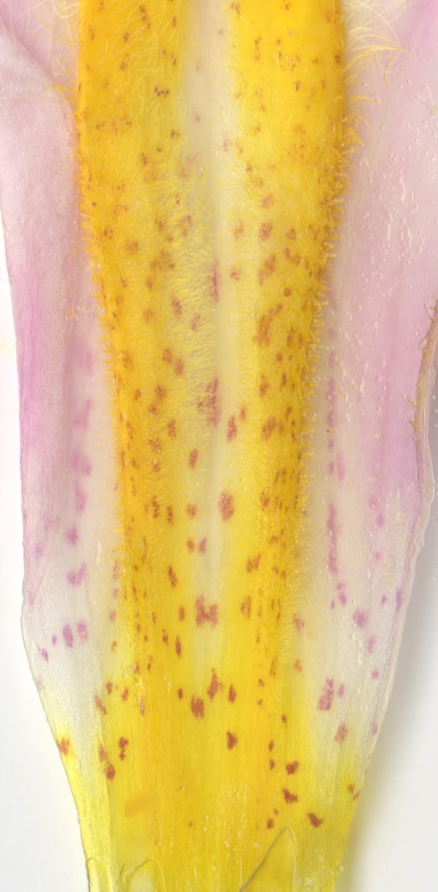

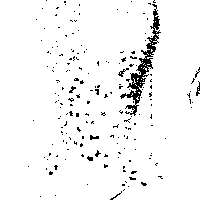

./content/real_images_6-29-25/6.png


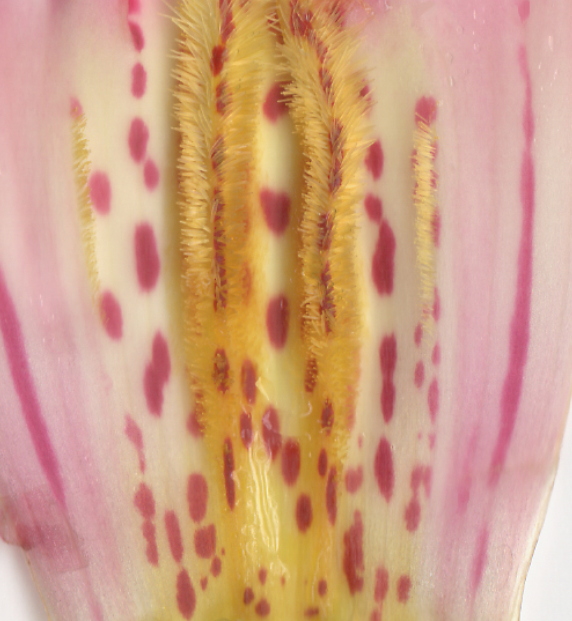

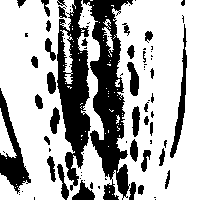

./content/real_images_6-29-25/7.png


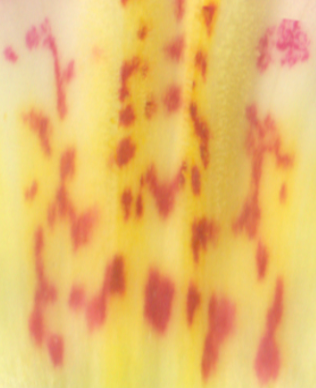

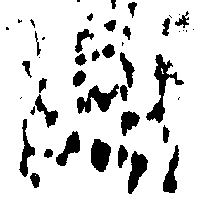

./content/real_images_6-29-25/8.png


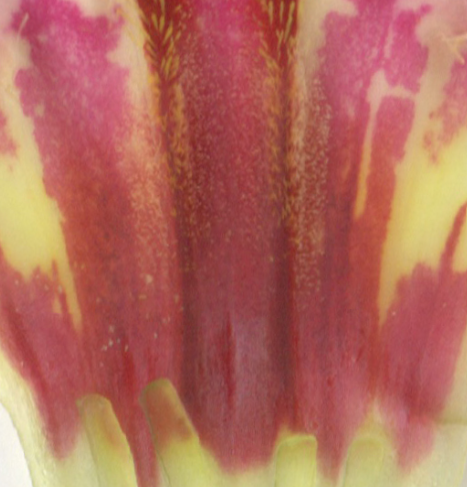

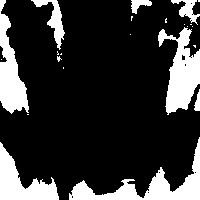

./content/real_images_6-29-25/9.png


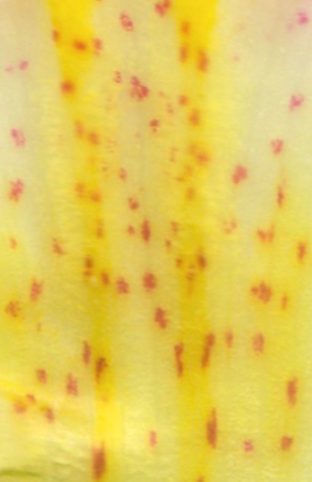

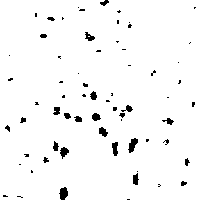

./content/real_images_6-29-25/10.png


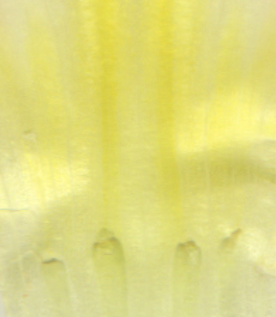

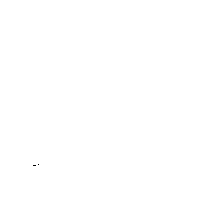

./content/real_images_6-29-25/11.png


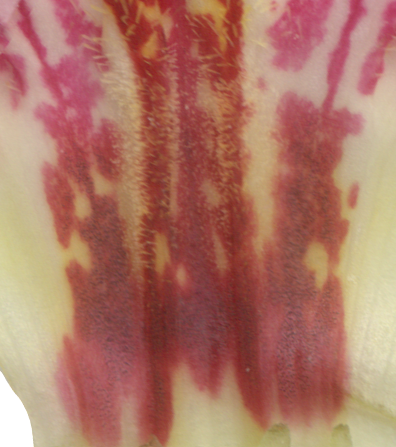

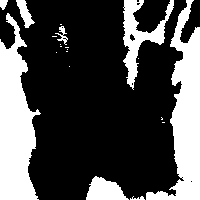

./content/real_images_6-29-25/12.png


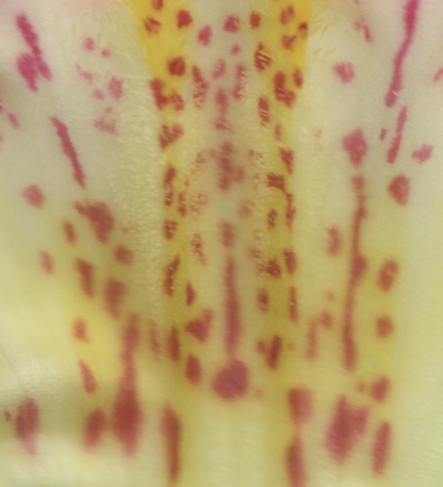

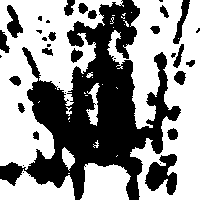

./content/real_images_6-29-25/13.png


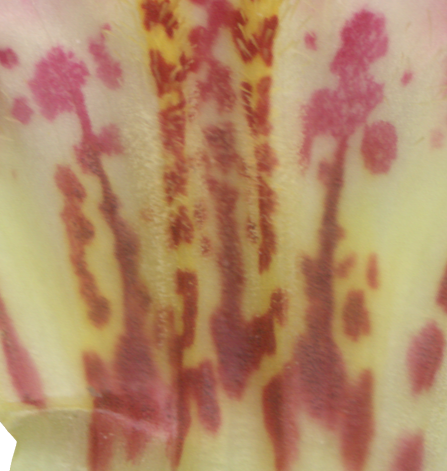

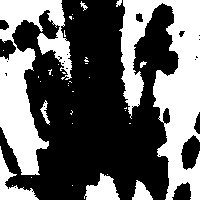

In [9]:
# Images
num_images = 13

# Goal: fine tune this number so that the function converts the images more properly.
default_threshold = 163

#Experimentation:
  # seperate threshold values per image
  # segmentation of images through UNet or basic segmentation

def to_silico(i,show=False, enhance=False, contrast_factor=1.5, threshold=default_threshold):
  """
    i - The location of the image in the data frame
    enhance - Whether to enhance the image. Defaults to True.
    show - Whether to display the image. Defaults to False.
    threshold - The threshold at which a pixel is either filled with white or black. Defaults to 163.
    contrast_factor - The factor to enhance the image by. Defaults to 1.5
  """
  filename, image_obj = pull_from_df(i, show=show)
  print(filename)
  display(image_obj)
  new_image_obj = round_pixels_by_intensity(image_obj, threshold=threshold, enhance=enhance, enhance_factor=contrast_factor)
  new_image_obj = new_image_obj.resize((200,200), Image.Resampling.LANCZOS) # Assign the resized image back to image_obj
  display(new_image_obj)

for x in range(0,num_images):
    to_silico(x)